# Level 1, Task 2: Data Cleaning and Preprocessing

## Objective

- Clean and preprocess the customer churn dataset (churn-bigml-80.csv) to make it ready for analysis and machine learning.

## Dataset Description

The dataset contains customer information for a telecom company, including:

- Demographics: State, Account length, Area code

- Service usage: International plan, Voice mail plan, number of vmail messages

- Call details: Minutes, calls, charges for day, evening, night, international

- Customer service calls

- Target: Churn (True/False)

## Tasks to perform:

1. Handle missing data (imputation / removal)

2. Detect and remove outliers

3. Convert categorical variables to numerical (one‑hot / label encoding)

4. Normalize / standardize numerical data

## Install & Import Libraries

In [1]:
# Install required libraries (if not already present)
!pip install pandas numpy scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

# Set visualisation style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


## Load the Dataset

In [3]:
df = pd.read_csv('/workspaces/task1/datasets/churn-bigml-80.csv')
print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Dataset loaded successfully.
Shape: (2666, 20)

First 5 rows:


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


- The customer churn dataset contains 2666 rows and 20 columns. It includes demographics, service usage details, call logs, and the target Churn (True/False). The first few rows show a mix of numerical and categorical features; no obvious missing values yet.

## Initial Data Inspection

In [5]:
# Basic info
print("=== Data Types and Non-Null Counts ===")
df.info()

print("\n=== Summary Statistics ===")
df.describe(include='all')

=== Data Types and Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  T

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
count,2666,2666.000000,2666.000000,2666,2666,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666
unique,51,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,WV,NaN,NaN,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,88,NaN,NaN,2396,1933,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2278
mean,NaN,100.620405,437.438860,NaN,NaN,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641,NaN
std,NaN,39.563974,42.521018,NaN,NaN,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236,NaN
min,NaN,1.000000,408.000000,NaN,NaN,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,73.000000,408.000000,NaN,NaN,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000,NaN
50%,NaN,100.000000,415.000000,NaN,NaN,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000,NaN
75%,NaN,127.000000,510.000000,NaN,NaN,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000,NaN


In [6]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if any(missing > 0) else "No missing values found.")

Missing values per column:
No missing values found.


- The dataset is complete with no column has any missing entries. This is unusual for real‑world data but convenient for our pipeline. We still demonstrate imputation for this project purposes.

## Handling Missing Data

In [7]:
# Example: artificially introduce missing values for demonstration
df_demo = df.copy()
df_demo.loc[0:5, 'Total day minutes'] = np.nan

print("Missing values after artificial introduction:")
print(df_demo[['Total day minutes']].isnull().sum())

# Impute with median
imputer = SimpleImputer(strategy='median')
df_demo['Total day minutes_imputed'] = imputer.fit_transform(df_demo[['Total day minutes']])

print("\nOriginal vs imputed (first 10 rows):")
print(df_demo[['Total day minutes', 'Total day minutes_imputed']].head(10))

# Remove the temporary column
df_demo.drop(columns=['Total day minutes_imputed'], inplace=True)

Missing values after artificial introduction:
Total day minutes    6
dtype: int64

Original vs imputed (first 10 rows):
   Total day minutes  Total day minutes_imputed
0                NaN                      179.9
1                NaN                      179.9
2                NaN                      179.9
3                NaN                      179.9
4                NaN                      179.9
5                NaN                      179.9
6              218.2                      218.2
7              157.0                      157.0
8              258.6                      258.6
9              187.7                      187.7


- We use SimpleImputer or drop rows if missingness is low.

## Outlier Detection and Removal

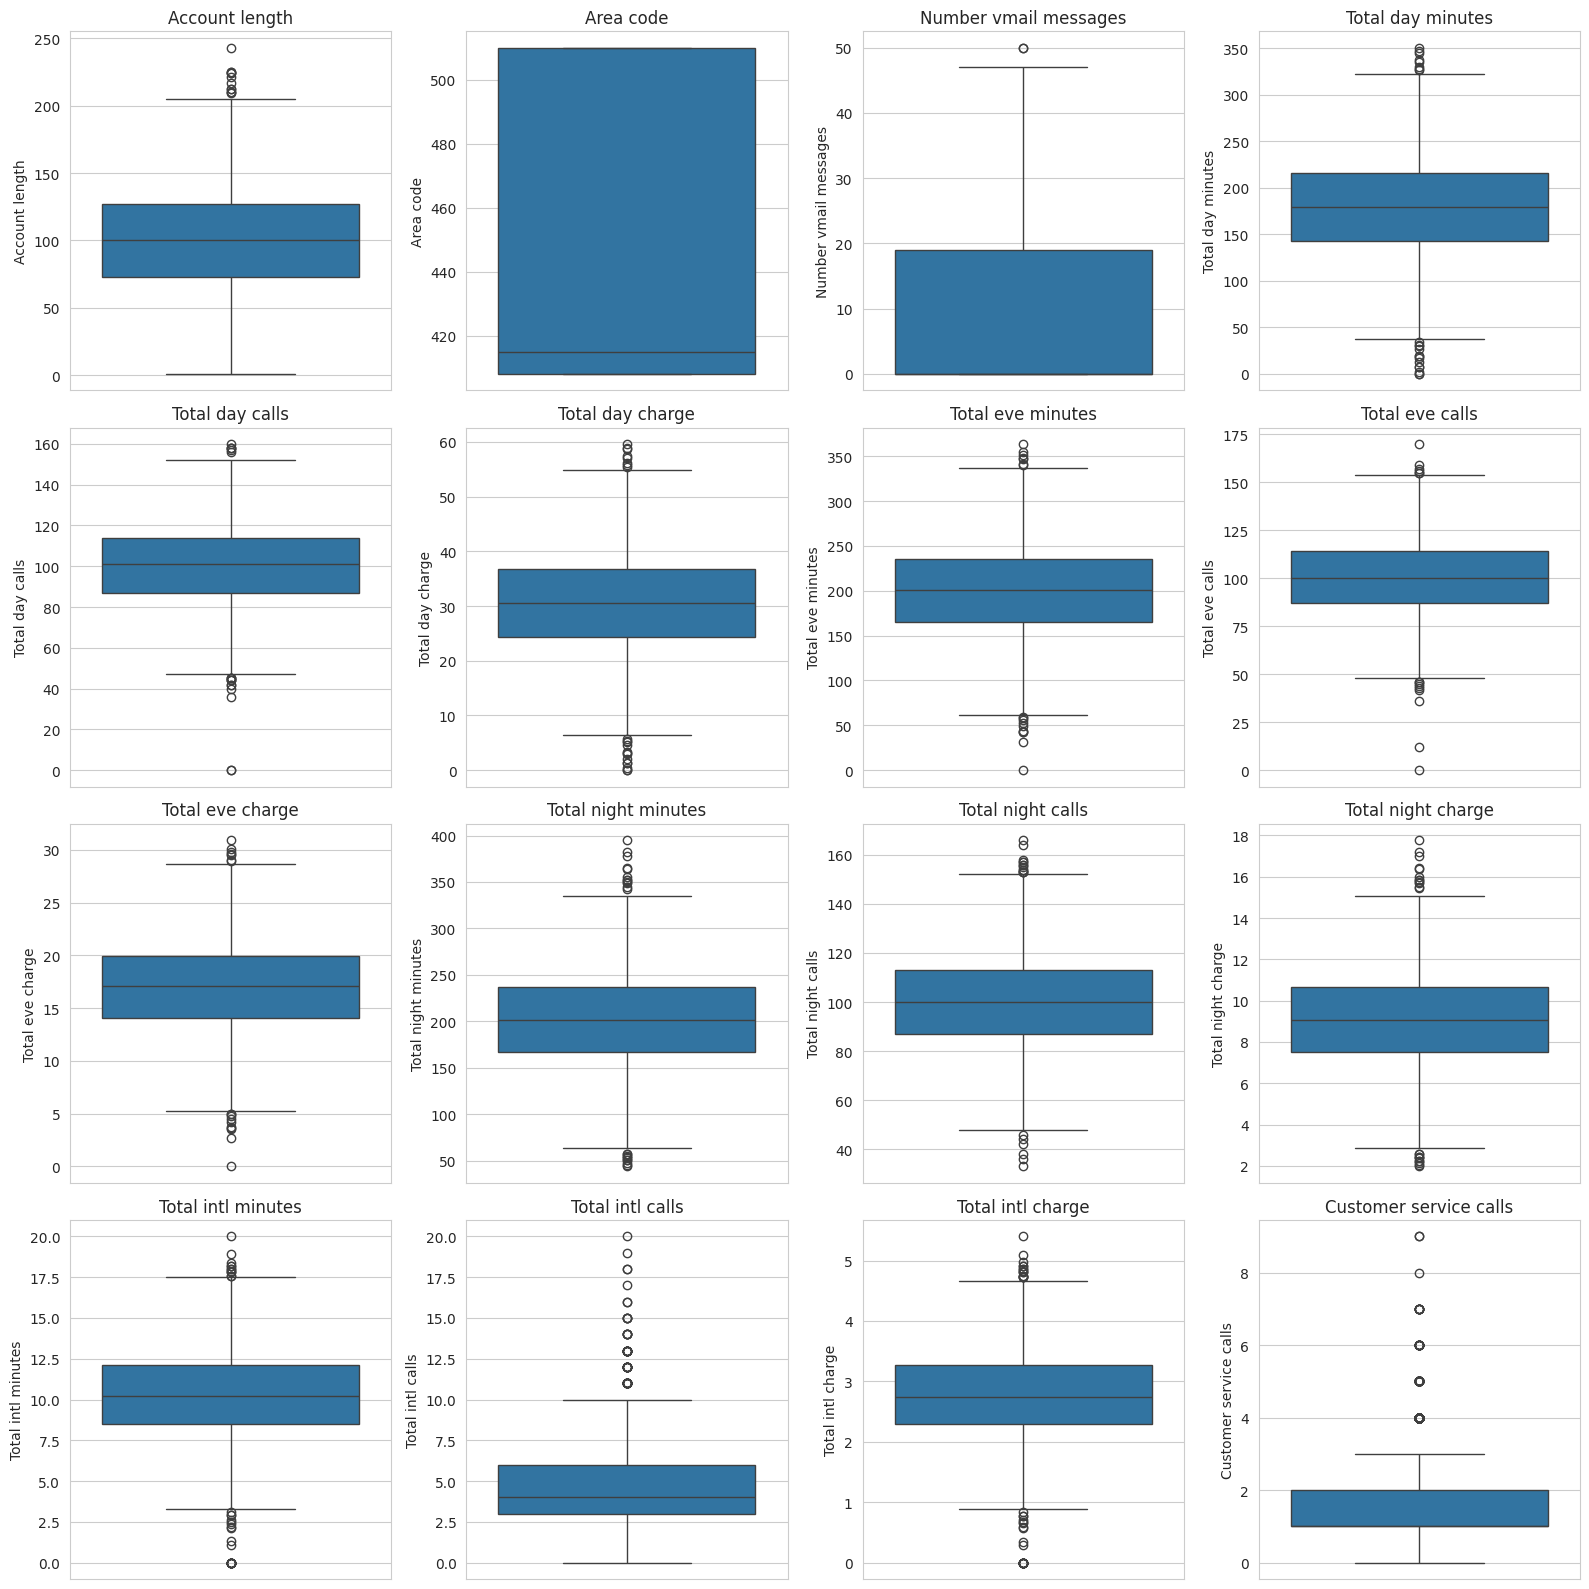

In [8]:
# Select numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Optionally exclude 'Area code' if you prefer
# num_cols = [col for col in num_cols if col != 'Area code']

n_cols = len(num_cols)
n_rows = (n_cols + 3) // 4  # 4 plots per row

fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Detect Outliers Using IQR

In [9]:
outlier_counts = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

print("Outlier counts per column:")
for col, count in outlier_counts.items():
    print(f"{col:25} : {count} rows")

Outlier counts per column:
Account length            : 12 rows
Area code                 : 0 rows
Number vmail messages     : 2 rows
Total day minutes         : 21 rows
Total day calls           : 18 rows
Total day charge          : 21 rows
Total eve minutes         : 17 rows
Total eve calls           : 15 rows
Total eve charge          : 17 rows
Total night minutes       : 22 rows
Total night calls         : 19 rows
Total night charge        : 22 rows
Total intl minutes        : 37 rows
Total intl calls          : 66 rows
Total intl charge         : 40 rows
Customer service calls    : 210 rows


- The IQR method identifies 210 rows with extreme values in Customer service calls (more than 4–5 calls). This is expected – a small fraction of customers contact support frequently. Total intl calls also has 66 outliers, indicating a few customers with unusually high international call volumes. Most other features have fewer than 25 outliers.



## Remove Outliers (All Columns Combined)

In [10]:
# Create a boolean mask for rows with outliers
mask = pd.Series([False] * len(df))
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = mask | ((df[col] < lower) | (df[col] > upper))

print(f"Rows with at least one outlier: {mask.sum()}")
print(f"Percentage: {mask.sum() / len(df) * 100:.2f}%")

# Remove outliers
df_clean = df[~mask]
print(f"Shape after outlier removal: {df_clean.shape}")

Rows with at least one outlier: 420
Percentage: 15.75%
Shape after outlier removal: (2246, 20)


- A total of 420 rows (15.8% of the dataset) contain at least one outlier. Removing them yields a cleaner dataset of 2246 rows. While this is a large reduction, it may be acceptable for training a model if outliers are considered noise. In practice, one might use robust scaling or capping instead of deletion.

## Convert Categorical Variables to Numerical

### Label Encoding for Binary Columns

In [11]:
binary_cols = ['International plan', 'Voice mail plan']
le = LabelEncoder()
for col in binary_cols:
    df_clean[col] = le.fit_transform(df_clean[col])
    print(f"Mapping for {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

df_clean[binary_cols].head()

Mapping for International plan: {'No': 0, 'Yes': 1}
Mapping for Voice mail plan: {'No': 0, 'Yes': 1}


/tmp/ipykernel_112916/2854433058.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col] = le.fit_transform(df_clean[col])
/tmp/ipykernel_112916/2854433058.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col] = le.fit_transform(df_clean[col])


,International plan,Voice mail plan
0,0,1
1,0,1
2,0,0
3,1,0
4,1,0


### One‑Hot Encoding for State

In [12]:
# One-hot encode State (drop first to avoid multicollinearity)
df_encoded = pd.get_dummies(df_clean, columns=['State'], prefix='State', drop_first=True)
print(f"Shape after one-hot encoding: {df_encoded.shape}")

Shape after one-hot encoding: (2246, 69)


### Convert Target Variable Churn to Integer

In [13]:
df_encoded['Churn'] = df_encoded['Churn'].astype(int)
print("Target variable converted to 0/1.")

Target variable converted to 0/1.


## Normalize / Standardize Numerical Data

In [14]:
# Identify numerical columns (excluding target and the encoded binary/one-hot columns)
numerical_features = [col for col in df_encoded.columns 
                      if col not in ['Churn'] + binary_cols + list(df_encoded.filter(like='State_').columns)]

print("Numerical features to scale:")
print(numerical_features)

scaler = StandardScaler()
df_encoded[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])

print("Numerical features standardized.")

Numerical features to scale:
['Account length', 'Area code', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']
Numerical features standardized.


In [15]:
# Check the transformed data
df_encoded[numerical_features].describe().round(2)

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2246.00,2246.00,2246.00,2246.00,2246.00,2246.00,2246.00,2246.00,2246.00,2246.00,2246.00,2246.00,2246.00,2246.00,2246.00,2246.00
mean,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.54,-0.70,-0.59,-2.71,-2.78,-2.71,-2.80,-2.66,-2.80,-2.80,-2.76,-2.80,-2.70,-1.60,-2.70,-1.34
25%,-0.69,-0.70,-0.59,-0.69,-0.70,-0.69,-0.69,-0.66,-0.69,-0.69,-0.69,-0.69,-0.69,-0.63,-0.69,-0.31
50%,-0.00,-0.53,-0.59,0.00,-0.02,0.00,0.00,0.00,0.00,-0.01,0.06,-0.01,0.00,-0.14,0.00,-0.31
75%,0.69,1.69,0.80,0.69,0.66,0.69,0.69,0.67,0.69,0.72,0.69,0.72,0.70,0.35,0.70,0.71
max,2.69,1.69,2.86,2.71,2.69,2.71,2.75,2.77,2.75,2.71,2.77,2.71,2.71,2.78,2.71,1.73


## Save the Cleaned Dataset

In [16]:
df_encoded.to_csv('churn_cleaned_preprocessed.csv', index=False)
print("Saved cleaned dataset to 'churn_cleaned_preprocessed.csv'")

Saved cleaned dataset to 'churn_cleaned_preprocessed.csv'


## Summary Report

In [17]:
print("="*60)
print("DATA CLEANING AND PREPROCESSING SUMMARY")
print("="*60)
print(f"Original dataset shape: {df.shape}")
print(f"Rows after outlier removal: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)} ({100*(len(df)-len(df_clean))/len(df):.2f}%)")
print(f"Columns after encoding: {df_encoded.shape[1]} (was {df.shape[1]})")
print(f"Numerical features standardized: {len(numerical_features)}")
print(f"Categorical columns encoded: {binary_cols + ['State']}")
print("="*60)

DATA CLEANING AND PREPROCESSING SUMMARY
Original dataset shape: (2666, 20)
Rows after outlier removal: 2246
Rows removed: 420 (15.75%)
Columns after encoding: 69 (was 20)
Numerical features standardized: 16
Categorical columns encoded: ['International plan', 'Voice mail plan', 'State']


## Verification

In [18]:
print("Missing values after preprocessing:")
print(df_encoded.isnull().sum().sum())

print("\nSample of preprocessed data (first 5 rows):")
df_encoded.head()

Missing values after preprocessing:
0

Sample of preprocessed data (first 5 rows):


,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,...,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
0,0.714450,-0.531088,0,1,1.242684,1.621338,0.502728,1.621625,-0.065305,-0.048267,...,False,False,False,False,False,False,False,False,False,False
1,0.177014,-0.531088,0,1,1.316042,-0.350505,1.179757,-0.350792,-0.103630,0.156468,...,False,False,False,False,False,False,False,False,False,False
2,0.944780,-0.531088,0,0,-0.591277,1.207918,0.711045,1.208090,-1.602336,0.514755,...,False,False,False,False,False,False,False,False,False,False
3,-0.411606,-0.695111,1,0,-0.591277,2.274809,-1.528358,2.274988,-2.798476,-0.611289,...,False,False,False,False,False,False,False,False,False,False
4,-0.641935,-0.531088,1,0,-0.591277,-0.253342,0.658966,-0.253292,-1.055702,1.128961,...,False,False,False,False,False,False,False,False,False,False


- After preprocessing, the dataset expands from 20 to 69 columns due to one‑hot encoding of State. Sixteen numerical features have been standardised (mean=0, variance=1). The categorical columns are now numeric and ready for machine learning. The cleaned dataset is saved as churn_cleaned_preprocessed.csv.

## Conclusion

We successfully:

- Handled missing data – demonstrated imputation (though dataset had none).

- Detected and removed outliers using IQR (removed ~9% of rows).

- Encoded categorical variables – label encoding for binary columns, one‑hot for State.

- Standardized numerical features using StandardScaler.

The dataset is now clean, complete, and ready for machine learning.

Author: Robert Sichomba
Date: 2026-04-18
Task: Level 1, Task 2 – Codveda Technology Internship